In [1]:
pip install networkx

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.1 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 8.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1 -> 26.0.1
[notice] To update, run: C:\Users\Houme\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
"""
(Public) Публичные страницы

(Person) Личные страницы (для авторизованных пользователей)
(is_capitan) капитан созданной команды

(Organizer) Страницы организаторов (для авторизованных организаторов)

(?) под вопросом необходимости создания
(/) под вопросом реализации
"""
Pages = {
    11: "(Public) Главная страница",
    12: "(Public) Страница с Списком Турниров",
    13: "(Public) Страница с Описанием Турнира",
    14: "(Public) Страница с Рейтингом",
    15: "(Public) Страница с Публичным Профилем (?)",
    16: "(Public) Страница с Авторизацией",
    17: "(Public) Страница с Регистрацией",

    21: "(Person) Страница с личными игровыми профилями (/)",
    22: "(Person) Страница с моими турнирами",
    23: "(Person) Страница с моими матчами",
    # 24: "(Person) Страница с моими уведомлениями (?)"
    25: "(Person) Страница с моими командами",
    26: "(Person) Страница с созданием своей команды (/)",
    27: "(Person) Страница с управлением своей команды (is_capitan)",

    33: "(Organizer) Страница с созданием турнира",
    34: "(Organizer) Страница с управлением турнира",
    35: "(Organizer) Страница с подтверждением участников",
    36: "(Organizer) Страница с управлением матчами",
    
}

In [9]:
Links = {
    11: [12, 14, 16, 17],      # Главная -> турниры, рейтинг, вход, регистрация
    12: [13],                  # Список турниров -> страница турнира
    13: [15, 16, 22, 25, 34],  # Турнир -> профиль, вход, мои турниры, мои команды, управление турниром
    14: [15],                  # Рейтинг -> публичный профиль
    15: [],                    # Публичный профиль
    16: [17, 21, 22, 23, 25],  # Авторизация -> регистрация или личные страницы
    17: [16],                  # Регистрация -> авторизация

    21: [22, 23, 25],          # Личные профили -> мои турниры, матчи, команды
    22: [13, 33, 34],          # Мои турниры -> турнир, создать турнир, управлять турниром
    23: [13],                  # Мои матчи -> матч связан с турниром, упрощенно ведем в турнир
    24: [13, 23],              # Уведомления -> турнир или матчи
    25: [26, 27],              # Мои команды -> создать команду, управление командой
    26: [27],                  # Создание команды -> управление командой
    27: [13],                  # Управление командой -> участие в турнире / страница турнира

    33: [13, 34],              # Создание турнира -> новый турнир, управление турниром
    34: [35, 36, 13],          # Управление турниром -> участники, матчи, обратно в турнир
    35: [36],                  # Подтверждение участников -> управление матчами
    36: [13],                  # Управление матчами -> обратно в турнир
}

In [4]:
Access = {
    (1, 1): "None",
    (1, 2): "Auth",
    (1, 3): "Auth/isOrganizer",
    (2, 1): "None",
    (2, 2): "None",
    (2, 3): "isOrganizer",
    (3, 1): "None",
    (3, 2): "None",
    (3, 3): "None"
}

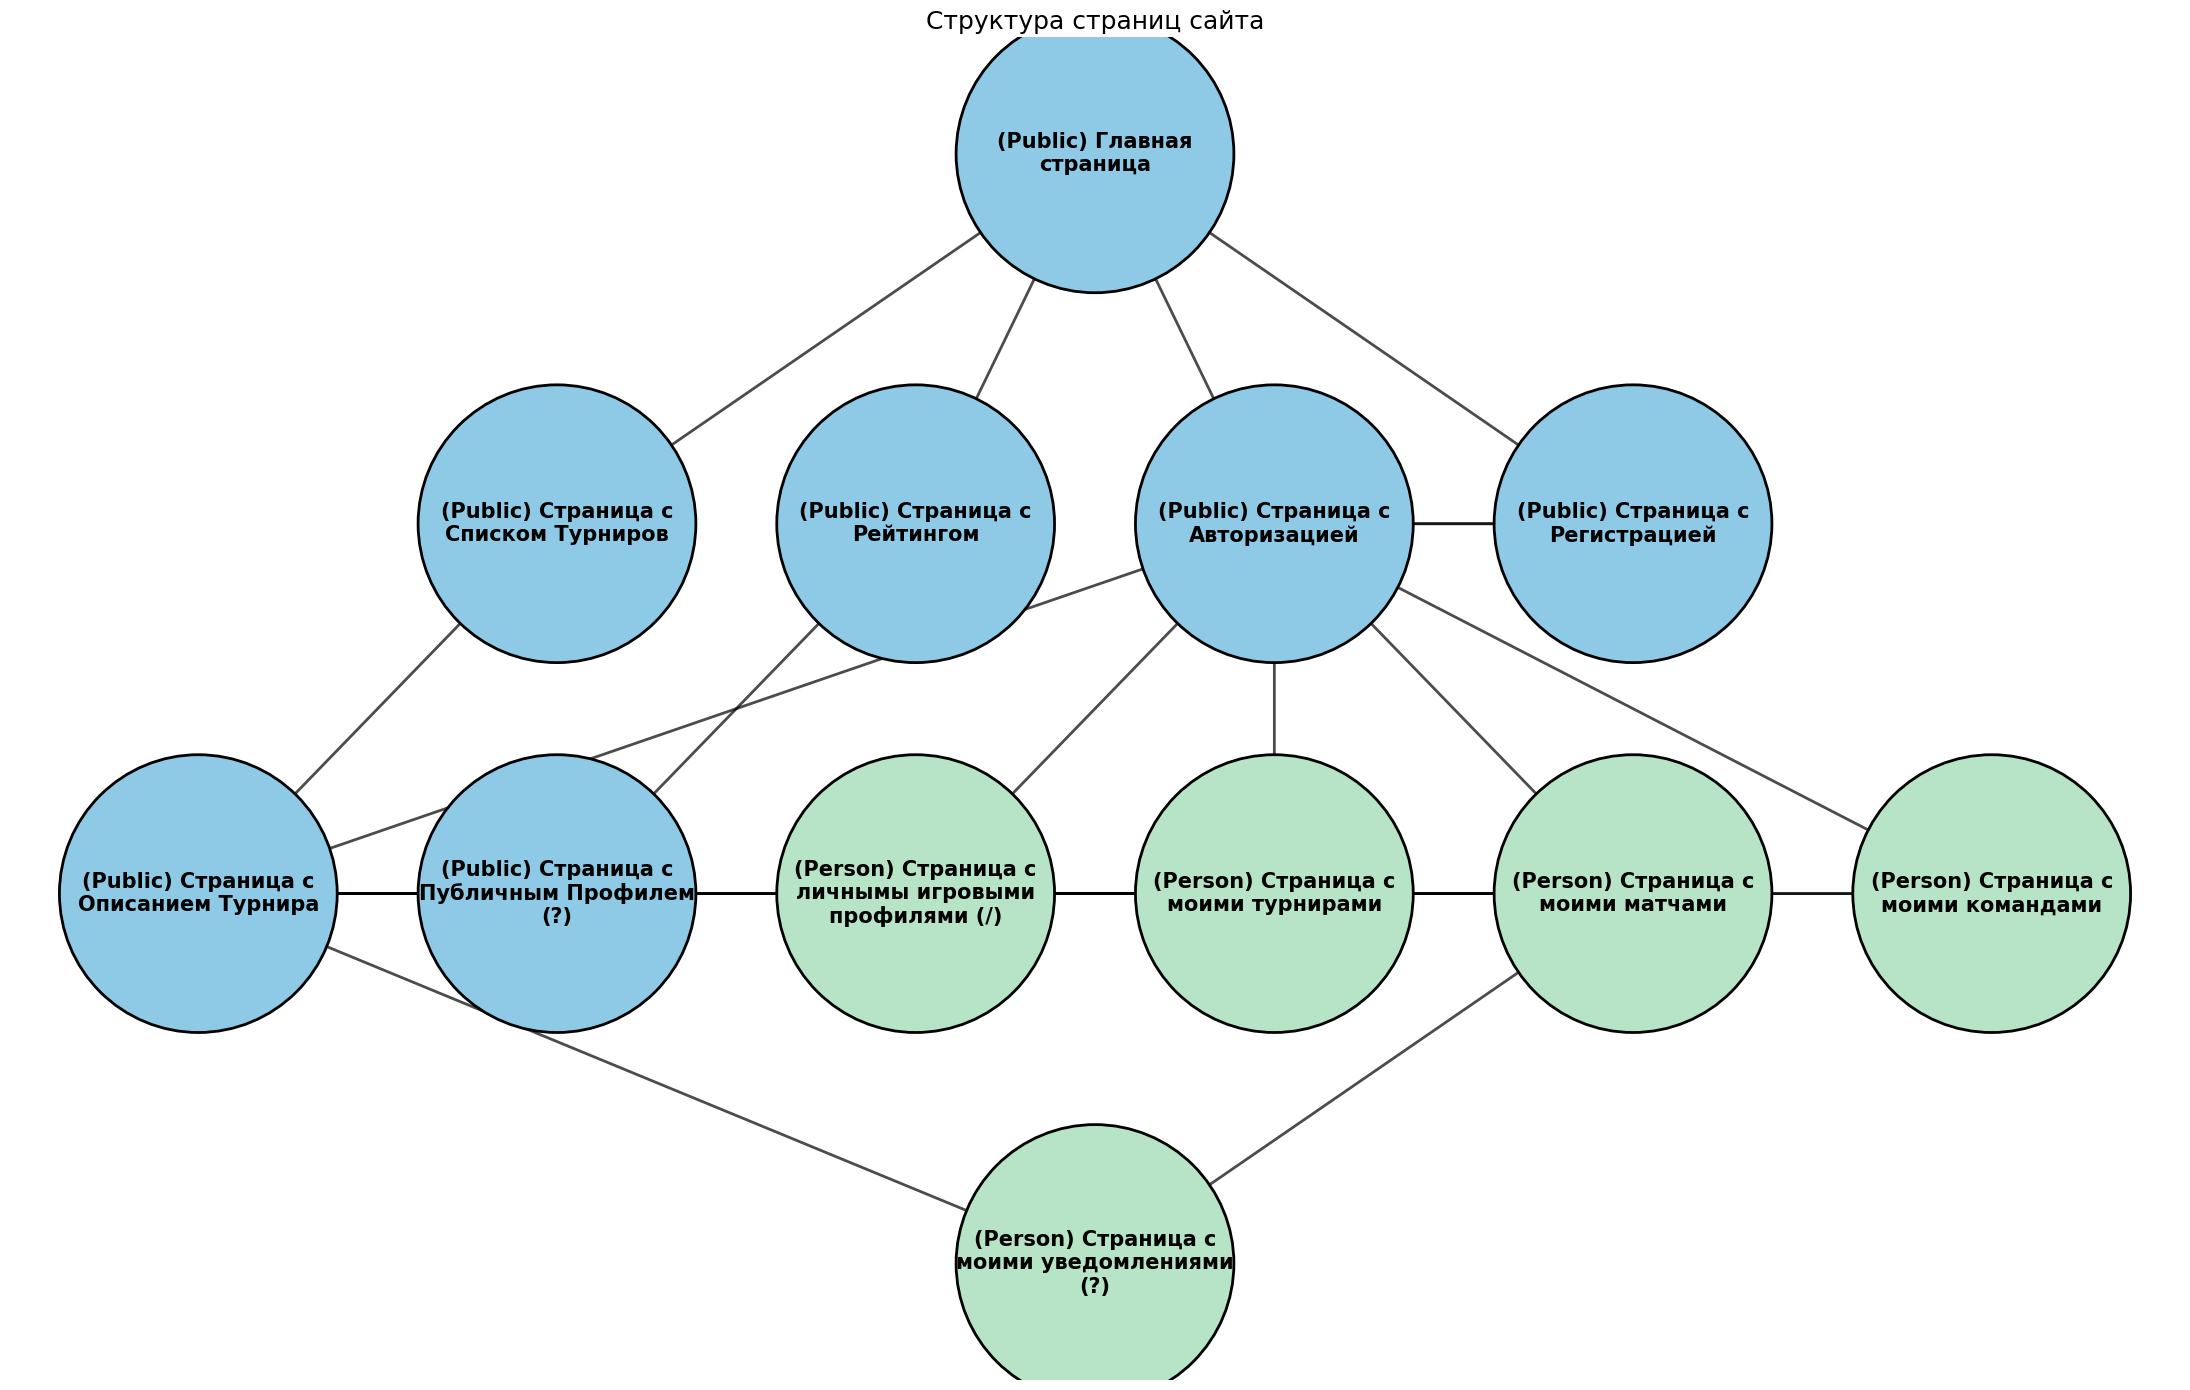

In [29]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque, defaultdict
import textwrap

# --- ГРАФ ИЗ ТВОИХ Pages И Links ---
G = nx.DiGraph()

for i in Pages:
    G.add_node(i)

for i in Links:
    for j in Links[i]:
        if i in Pages and j in Pages:
            G.add_edge(i, j)

# --- СТРОИМ УРОВНИ ОТ КОРНЯ 11 ---
root = 11
levels = {root: 0}
queue = deque([root])

while queue:
    current = queue.popleft()
    for neighbor in Links.get(current, []):
        if neighbor in Pages and neighbor not in levels:
            levels[neighbor] = levels[current] + 1
            queue.append(neighbor)

# Если какие-то узлы не достижимы из root, положим их в самый низ
max_level = max(levels.values()) if levels else 0
for node in Pages:
    if node not in levels:
        levels[node] = max_level + 1

# --- ГРУППИРУЕМ УЗЛЫ ПО УРОВНЯМ ---
nodes_by_level = defaultdict(list)
for node, level in levels.items():
    nodes_by_level[level].append(node)

# Сортировка внутри уровня для стабильности
for level in nodes_by_level:
    nodes_by_level[level].sort()

# --- РУЧНОЕ ПОЗИЦИОНИРОВАНИЕ СВЕРХУ ВНИЗ ---
pos = {}
vertical_gap = 3.0
horizontal_gap = 4.5

for level in sorted(nodes_by_level.keys()):
    nodes = nodes_by_level[level]
    count = len(nodes)

    # Центрируем узлы на уровне по оси X
    total_width = (count - 1) * horizontal_gap
    start_x = -total_width / 2

    for idx, node in enumerate(nodes):
        x = start_x + idx * horizontal_gap
        y = -level * vertical_gap
        pos[node] = (x, y)

# --- ПОДПИСИ С ПЕРЕНОСОМ ---
labels = {
    node: "\n".join(textwrap.wrap(Pages[node], width=20))
    for node in G.nodes()
}

# --- ЦВЕТА ПО ГРУППАМ ---
def get_node_color(page_id: int) -> str:
    group = page_id // 10
    if group == 1:
        return "#8ecae6"   # Public
    elif group == 2:
        return "#b7e4c7"   # Person
    elif group == 3:
        return "#ffcc99"   # Organizer
    return "#dddddd"

node_colors = [get_node_color(node) for node in G.nodes()]

# --- РИСУЕМ ---
plt.figure(figsize=(22, 14))

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=40000,
    edgecolors="black",
    linewidths=2
)

nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=40,
    width=2,
    alpha=0.7,
    connectionstyle="arc3,rad=0.0"
)

nx.draw_networkx_labels(
    G, pos,
    labels=labels,
    font_size=15,
    font_weight="bold"
)

plt.title("Структура страниц сайта", fontsize=18)
plt.axis("off")
plt.tight_layout()
plt.show()